In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# CA-011-01-six-stage-sector-rotation

Theory **CA-011**. The battery's verdict: the strategy stops at gate 3, significance: beats 80.1% of its shifted placebos, fewer than 90%.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** Sectors respond differently to growth, inflation and interest rates, and investors identify the phase of the cycle slowly, so that leadership passes in sequence from sector to sector. Bonds, stocks and commodities turn in a regular order around the cycle, so that their three trends place it: bonds turning up as the economy slips into recession, then stocks, then commodities, then bonds turning down, then stocks, then commodities. The sectors that lead each phase -- staples, utilities and real estate early in a contraction, utilities, financials and consumer cyclicals late in it, technology, industrials and consumer cyclicals early in an expansion, energy and materials late in it -- outperform the sectors held always while the stage lasts, and the asset classes each stage favours outperform with them.

**Prediction.** sign: positive (the sectors of each stage, held while it lasts, earn more than the sector funds held in equal parts), size: a judgment -- the sources give charts and episodes, not statistics; for the sectors alone, graded, an appraisal ratio of about 0 to 0.2 against the sector funds in equal parts, an alpha of about 0 to 2% a year on a tracking error of about 8 to 10%, the average mix's own tilt about -0.2 to -0.4% a year by TM-002-01's published sector alphas; for the base against the fifteen funds, about 0 to 0.2; CA-014-01's sector funds, rotated on the commodity/bond ratio, earned 0.04 against their sectors; the base expected to fail gates 3, 4 and 5, possibly gate 2

**What would refute it.** Judged on the variant "sectors", at the lab's stated costs, by its appraisal ratio against the sector funds that trade held in equal parts, reset on each session the variant sets targets and when a fund starts to trade (XLRE from 2016-09-19, XLC from 2018-06-19), at the same costs -- the battery's benchmark built on the eleven sector funds alone -- over the in-sample sessions from the first the variant holds an asset into, computed apart from the battery: the annualised Sharpe ratio of the variant's daily returns less the benchmark's, hedged of the benchmark's excess returns with the whole-sample beta. The theory is refuted in this form if that ratio is zero or less: the sectors Pring's stage names, held in turn, earned nothing over the sectors held always, as the bank's first refutation reads. Any other result short of the base passing gates 1 to 7 is not proven, not refuted; a base that passes gates 1 to 7 while the clause refutes leaves the theory refuted in this form. The second refutation, sectors adjusting at once, is not graded: gate 6's day of delay reads the speed only coarsely; the third is not graded: the lab cannot tell a shock or an intervention from a regime. The published results of CA-014-01, TM-002-01, TM-017-01, TM-018-01, TM-001-01, LL-042-01, CA-006-01, TM-003-01 and CA-003-01, their years, sectors and holdings, and the registry's monthly hedged returns of CA-014-01, from which nothing was computed, stay, disclosed. Reported, not graded: the base's figures, as the battery gives them, and the variant "assets"'s appraisal ratio against the fifteen funds; the variant "sectors"'s average weights, held fixed and reset weekly, against the same sector benchmark, to tell its tilt from its timing; each stage's share of the sessions, and the mean daily difference between the variant "sectors"'s and its benchmark's returns, annualised, over the sessions held under each stage and out of sequence; the clause's hedged daily series restricted to the sessions held under one of the six stages, with the whole-sample beta, and restricted to 2006 to 2013 and to 2014 to 2022; the correlation of the variant "sectors"'s monthly returns hedged of its sector benchmark with CA-014-01's variant "stocks" as the registry gives it, hedged of its nine funds, over their common months; the alpha by year.

**Horizon.** weeks to months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY, SPY, GLD, DBC, IEF. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2006-11-21, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

On the first session of each week, each of IEF, SPY and DBC is up if its signal close on the session before is above the mean of its last average closes up to and including that session; the three trends are read from the signal prices whether IEF, SPY and DBC trade or not. The three signs give Pring's stage: 1, IEF up, SPY and DBC down; 2, IEF and SPY up, DBC down; 3, all three up; 4, IEF down, SPY and DBC up; 5, IEF and SPY down, DBC up; 6, all three down; the two other combinations are out of sequence. Under holdings "sectors", stage 1 holds XLP, XLU and XLRE; stage 2 XLU, XLF and XLY; stage 3 XLK, XLI and XLY; stage 4 XLE and XLB; stage 5 XLE and XLP; stage 6 XLP and XLU; out of sequence, the eleven sector funds. Under holdings "assets", stage 1 holds IEF; stage 2 SPY; stage 3 SPY and GLD; stage 4 DBC and GLD; stage 5 DBC, GLD and XLE; stage 6 nothing, all in cash; out of sequence, the fifteen funds. Under holdings "all", each stage holds the funds of both lists -- stage 1 XLP, XLU, XLRE and IEF; stage 2 XLU, XLF, XLY and SPY; stage 3 XLK, XLI, XLY, SPY and GLD; stage 4 XLE, XLB, DBC and GLD; stage 5 XLE, XLP, DBC and GLD; stage 6 XLP and XLU -- and out of sequence the fifteen funds. The funds named that trade share the portfolio equally; if none trades, the targets are zero on every fund. The targets start on the first session of the first week at which all three means exist, and are set on the first session of every week from then.

- **average**: sessions of closes averaged to give each market's trend, Murphy's 200-day moving average
- **holdings**: "all" holds each stage's sectors with Murphy's asset classes for it; "sectors" the sectors alone; "assets" the asset classes alone

,average,holdings
base,200,all
variant 1,200,sectors
variant 2,200,assets


Parameter neighbours, moved one at a time for gate 6: average at ±25%: 150, 250; average at ±50%: 100, 300.

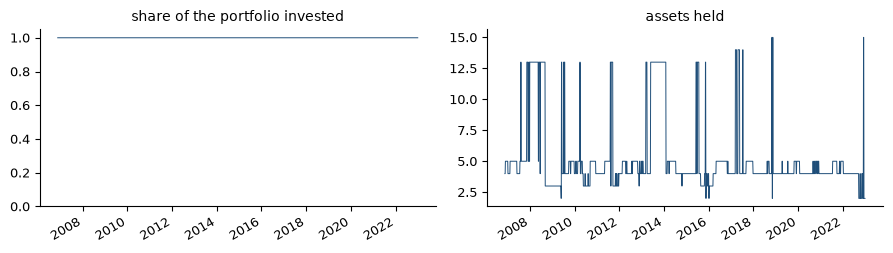

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

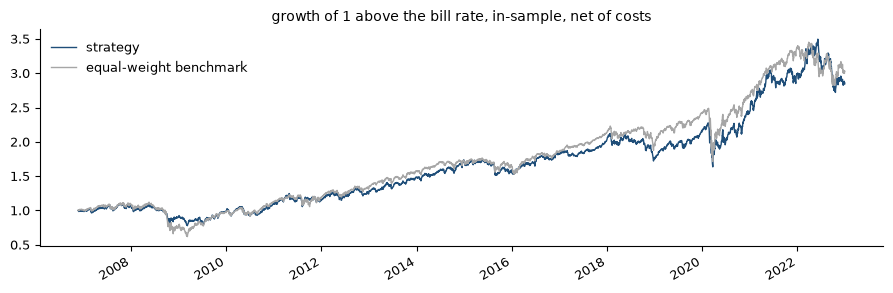

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 300 dates, 149 decisions over 16.1 years.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,300,0,0,301,150,0,none,149,16.1,5


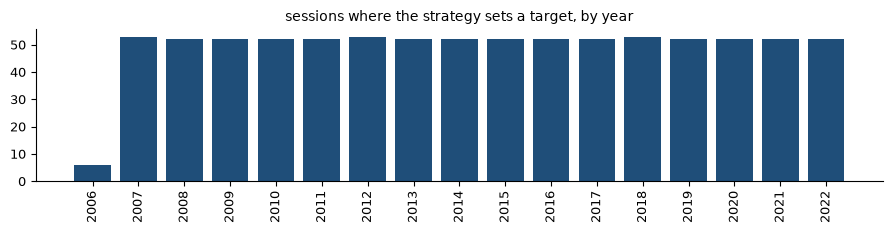

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Passes**: Sharpe 0.51 against the benchmark's 0.51, alpha 1.21%, 0.47 at twice the costs.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.5129,0.5068,0.01213,0.4656,0.005431,0.5601,0.006997,0.04724


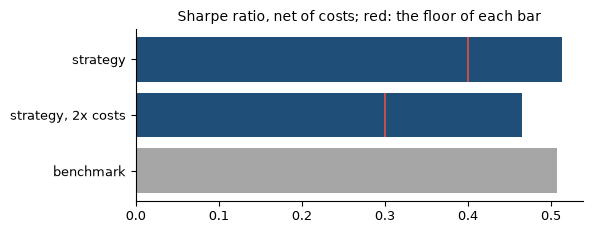

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Fails**: beats 80.1% of its shifted placebos, fewer than 90%.

,PSR,placebo sessions,placebos,placebos beaten
,0.9881,4056,1000,0.801


Assets that start trading after 2006-11-20: XLC, XLRE. A placebo shifts their weights only between days when they trade. Where it draws from a day before their start, it keeps their own weights; where it draws from a day after their start onto a day before it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its timing: skill that lies before a late start is judged against placebos that share it, and is found less often. Where the strategy holds none of the assets shifted that day, the shifted weights take that share instead.

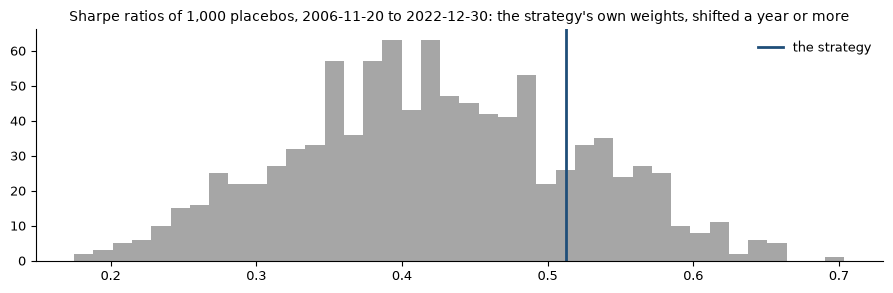

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.038 below 0.9 over 69 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,76,69,0.1557,0.6142,0.03835


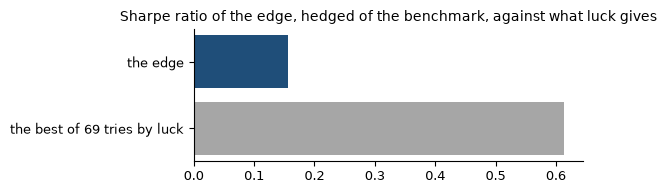

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gate 4; alpha positive in 2 of 5 blocks, fewer than 3.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,True,True,False,0.4927,2,2008,0.000533


The blend of the variants: gate 4, DSR 0.096 below 0.9 over 69 effective trials.

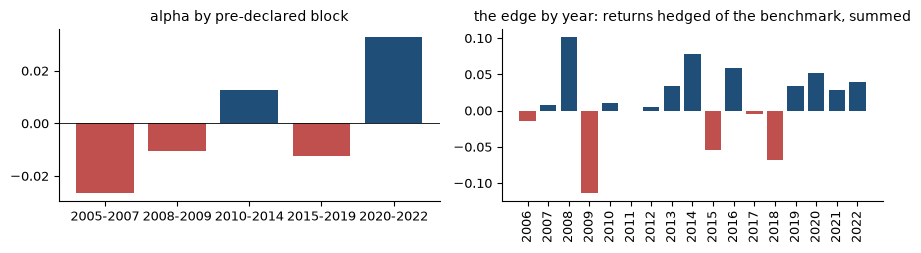

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Passes**: neighbours, clusters, assets, bitcoin, delay and survivors all hold.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,0.9826,0.9436,none,sectors,0.8413,0.2167,XLE,1.014,—,—


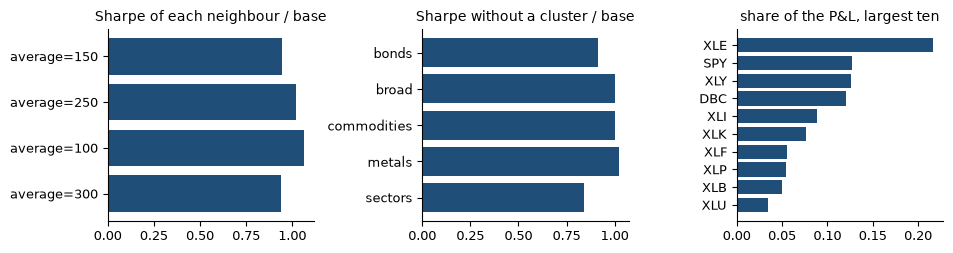

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 0.87 and alpha 0.77%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,0.8658,-0.184,0.007676,-0.04959,0,60,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

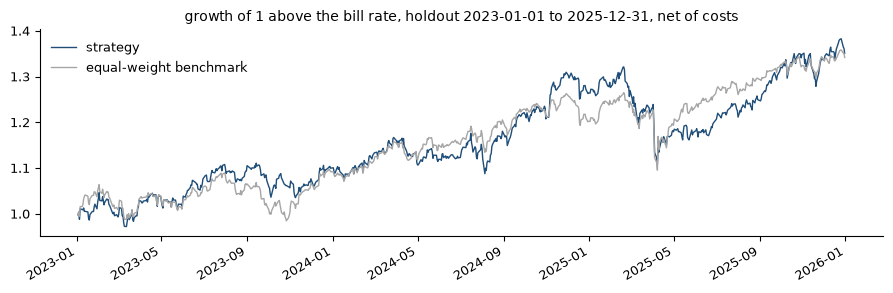

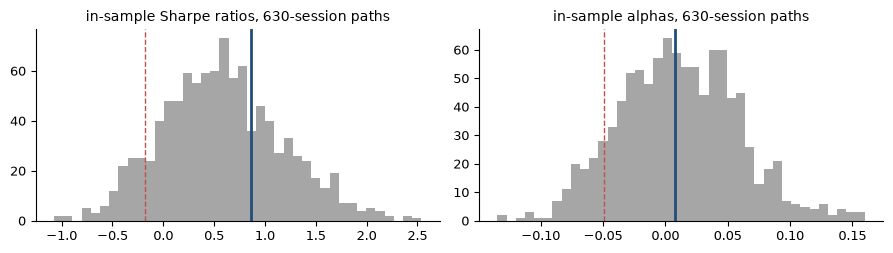

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 300 dates, 149 decisions over 16.1 years"
2 · Economic edge,passes,"Sharpe 0.51 against the benchmark's 0.51, alpha 1.21%, 0.47 at twice the costs"
3 · Significance,fails,"beats 80.1% of its shifted placebos, fewer than 90%"
4 · Multiple testing,fails,DSR 0.038 below 0.9 over 69 effective trials
5 · Stability,fails,"the blend of the variants fails gate 4; alpha positive in 2 of 5 blocks, fewer than 3"
6 · Robustness,passes,"neighbours, clusters, assets, bitcoin, delay and survivors all hold"
7 · Sealed holdout,passes,"holdout Sharpe 0.87 and alpha 0.77%, both above the in-sample 10th percentile"


Thresholds, version 4. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).